# Batch size and domain alignment — batch 32 vs 128

## Why this experiment

To tell whether DA failed because of **a limitation of the methods or an optimisation problem**.

Raising λ from 0 to 300 on f_u fold 0 showed:

| λ | domain AUC | test R² |
|---|---|---|
| 0 | 0.870 | 0.213 |
| 1 | 0.729 | 0.055 |
| 10 | **0.689** | −0.038 |
| 100 | 0.767 | −0.046 |

AUC never went below 0.69, and with larger λ it **went back up**. Non-monotonic behaviour means
unstable optimisation, and the suspected cause was **estimating MMD from batches of 32**.
Measuring a distribution distance from 32 vs 32 samples in a 128-d space has high estimation variance.

So the same experiment is repeated with a larger batch.
A larger batch means fewer steps per epoch, so **max_epochs and patience were scaled up to keep the total number of steps**
(batch 128 → max_epochs 320, patience 60).

> **How to read**
> - If a larger batch lowers AUC further and R² holds → the earlier failure was **an optimisation problem**.
> - If AUC does not drop even with a larger batch → it is a property of the data that **alignment and prediction are incompatible**.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel

ROOT = r'..'
RES = os.path.join(ROOT, 'results')
FIG = os.path.join(RES, 'figures')

PROPS = ['fu', 'clearance', 'half_life']
LABEL = {'fu': 'f_u', 'clearance': 'CL', 'half_life': 't½'}
COLOR = {'fu': '#1a7f37', 'clearance': '#0969da', 'half_life': '#cf222e'}
METHODS = ['MMD', 'CORAL', 'DANN', 'CDAN', 'Importance Weighting']
SHORT = {'MMD': 'MMD', 'CORAL': 'CORAL', 'DANN': 'DANN', 'CDAN': 'CDAN', 'Importance Weighting': 'IW'}
METRICS = [('r', 'Pearson r', True), ('r2', 'R²', True),
           ('mae', 'MAE', False), ('rmse', 'RMSE', False)]      # (column, display name, higher is better)

norm = pd.read_csv(os.path.join(ROOT, 'data', 'cv_datasets', 'target_norm_stats.csv')).rename(
    columns={'Fold': 'fold', 'Property': 'property'})


def load(path, batch):
    # Load runs.csv. Error metrics are converted to log10 units; earlier runs without Pearson r are left as NaN.
    d = pd.read_csv(path).merge(norm, on=['fold', 'property'])
    for c in ('mae', 'rmse'):
        d[c] = d[c] * d['log10_std']
    if 'r' not in d:
        d['r'] = np.nan
    return d.assign(batch=batch)


b32_path = os.path.join(RES, 'significance_mae', 'runs.csv')
if not os.path.exists(b32_path):
    b32_path = os.path.join(RES, 'significance', 'runs.csv')
b128_path = os.path.join(RES, 'significance_b128', 'runs.csv')

frames = [load(b32_path, 32)]
if os.path.exists(b128_path):
    frames.append(load(b128_path, 128))
else:
    print('No batch 128 results yet — re-run after the run finishes')
runs = pd.concat(frames, ignore_index=True)

# If the two runs have different numbers of seeds, compare on the shared seeds
common = sorted(set.intersection(*[set(runs[runs.batch == b]['seed']) for b in runs.batch.unique()]))
runs = runs[runs.seed.isin(common)]
print('batch:', sorted(runs.batch.unique()), '| shared seeds:', common)
print('MAE and RMSE converted to log10 units')

pd.set_option('display.width', 220)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.color': '#e6e5e0', 'grid.linewidth': 0.6, 'axes.axisbelow': True})

batch: [32, 128] | shared seeds: [0, 1, 2, 3, 4]
MAE and RMSE converted to log10 units


## 1. Overall performance on four metrics

Each cell is the seed and fold mean. Baseline is the target-only model of each batch setting.

In [2]:
tab = (runs.groupby(['batch', 'property', 'method'])[[m for m, _, _ in METRICS]].mean()
       .rename(columns={m: n for m, n, _ in METRICS}))
order = ['Baseline'] + METHODS
view = tab.reset_index()
view['property'] = view['property'].map(LABEL)
view = view.set_index(['property', 'batch', 'method']).loc[
    [(LABEL[p], b, m) for p in PROPS for b in sorted(runs.batch.unique()) for m in order
     if (LABEL[p], b, m) in view.set_index(['property', 'batch', 'method']).index]]
view.round(4)

Pearson r      R²     MAE    RMSE
property batch method                                                 
f_u      32    Baseline                    NaN  0.2514  0.5439  0.6779
               MMD                         NaN  0.2344  0.5529  0.6863
               CORAL                       NaN  0.2558  0.5551  0.6787
               DANN                        NaN  0.2326  0.5556  0.6876
               CDAN                        NaN  0.2676  0.5485  0.6730
               Importance Weighting        NaN  0.2495  0.5424  0.6778
         128   Baseline                 0.5548  0.2347  0.5494  0.6852
               MMD                      0.5295  0.1852  0.5816  0.7094
               CORAL                    0.5665  0.2522  0.5522  0.6813
               DANN                     0.5419  0.2081  0.5699  0.6985
               CDAN                     0.5665  0.2642  0.5494  0.6738
               Importance Weighting     0.5773  0.2621  0.5381  0.6733
CL       32    Baseline                    NaN  0.0918  0.4595  0.6173
               MMD                         NaN  0.1017  0.4574  0.6140
               CORAL                       NaN  0.1010  0.4580  0.6141
               DANN                        NaN  0.0847  0.4621  0.6196
               CDAN                        NaN  0.1054  0.4549  0.6125
               Importance Weighting        NaN  0.0896  0.4611  0.6180
         128   Baseline                 0.3696  0.0997  0.4581  0.6140
               MMD                      0.3557  0.0838  0.4599  0.6196
               CORAL                    0.3799  0.1019  0.4516  0.6131
               DANN                     0.3628  0.0857  0.4587  0.6182
               CDAN                     0.3674  0.1165  0.4515  0.6086
               Importance Weighting     0.3655  0.0903  0.4602  0.6173
t½       32    Baseline                    NaN  0.0923  0.4463  0.5869
               MMD                         NaN  0.0780  0.4500  0.5903
               CORAL                       NaN  0.0808  0.4504  0.5900
               DANN                        NaN  0.0725  0.4518  0.5925
               CDAN                        NaN  0.0799  0.4501  0.5903
               Importance Weighting        NaN  0.0829  0.4493  0.5896
         128   Baseline                 0.3860  0.0903  0.4483  0.5868
               MMD                      0.3722  0.0850  0.4487  0.5889
               CORAL                    0.3659  0.0697  0.4512  0.5930
               DANN                     0.3794  0.0838  0.4483  0.5893
               CDAN                     0.3788  0.0840  0.4483  0.5889
               Importance Weighting     0.3731  0.0778  0.4514  0.5907

## 2. Change vs baseline — batch settings side by side

Seed mean per fold, then a paired t-test against that batch setting's Baseline (n = 5 folds).
MAE and RMSE are sign-flipped as **baseline − method**, so that **positive = better** for every metric.

In [3]:
rows = []
for b in sorted(runs.batch.unique()):
    d_b = runs[runs.batch == b]
    for prop in PROPS:
        d = d_b[d_b.property == prop]
        for m in METHODS:
            if m not in d.method.unique():
                continue
            row = {'batch': b, 'endpoint': LABEL[prop], 'method': SHORT[m]}
            for col, name, higher in METRICS:
                a = d[d.method == m].groupby('fold')[col].mean()
                base = d[d.method == 'Baseline'].groupby('fold')[col].mean()
                if a.isna().all() or base.isna().all():
                    row[name], row[f'p({name})'] = np.nan, np.nan
                    continue
                diff = (a - base) if higher else (base - a)
                row[name] = diff.mean()
                row[f'p({name})'] = ttest_rel(a, base).pvalue
            rows.append(row)
delta = pd.DataFrame(rows)
delta.to_csv(os.path.join(RES, 'significance_b128', 'delta_by_batch.csv'),
             index=False, encoding='utf-8-sig')
delta.pivot_table(index=['endpoint', 'method'], columns='batch',
                  values=[n for _, n, _ in METRICS]).round(4)

MAE         Pearson r    RMSE              R²        
batch               32      128       128     32      128     32      128
endpoint method                                                          
CL       CDAN    0.0046  0.0066   -0.0022  0.0048  0.0053  0.0136  0.0168
         CORAL   0.0015  0.0065    0.0102  0.0032  0.0008  0.0092  0.0022
         DANN   -0.0026 -0.0006   -0.0069 -0.0023 -0.0043 -0.0071 -0.0140
         IW     -0.0016 -0.0021   -0.0041 -0.0006 -0.0033 -0.0022 -0.0094
         MMD     0.0021 -0.0018   -0.0139  0.0034 -0.0056  0.0099 -0.0159
f_u      CDAN   -0.0046 -0.0000    0.0117  0.0049  0.0113  0.0162  0.0294
         CORAL  -0.0112 -0.0028    0.0117 -0.0008  0.0039  0.0044  0.0175
         DANN   -0.0117 -0.0205   -0.0129 -0.0098 -0.0133 -0.0188 -0.0266
         IW      0.0014  0.0113    0.0225  0.0001  0.0119 -0.0020  0.0274
         MMD    -0.0090 -0.0322   -0.0253 -0.0084 -0.0243 -0.0170 -0.0496
t½       CDAN   -0.0038 -0.0001   -0.0073 -0.0035 -0.0020 -0.0124 -0.0063
         CORAL  -0.0040 -0.0030   -0.0201 -0.0031 -0.0062 -0.0115 -0.0206
         DANN   -0.0054 -0.0001   -0.0066 -0.0056 -0.0024 -0.0198 -0.0065
         IW     -0.0029 -0.0031   -0.0129 -0.0027 -0.0039 -0.0094 -0.0125
         MMD    -0.0037 -0.0005   -0.0138 -0.0034 -0.0021 -0.0143 -0.0052

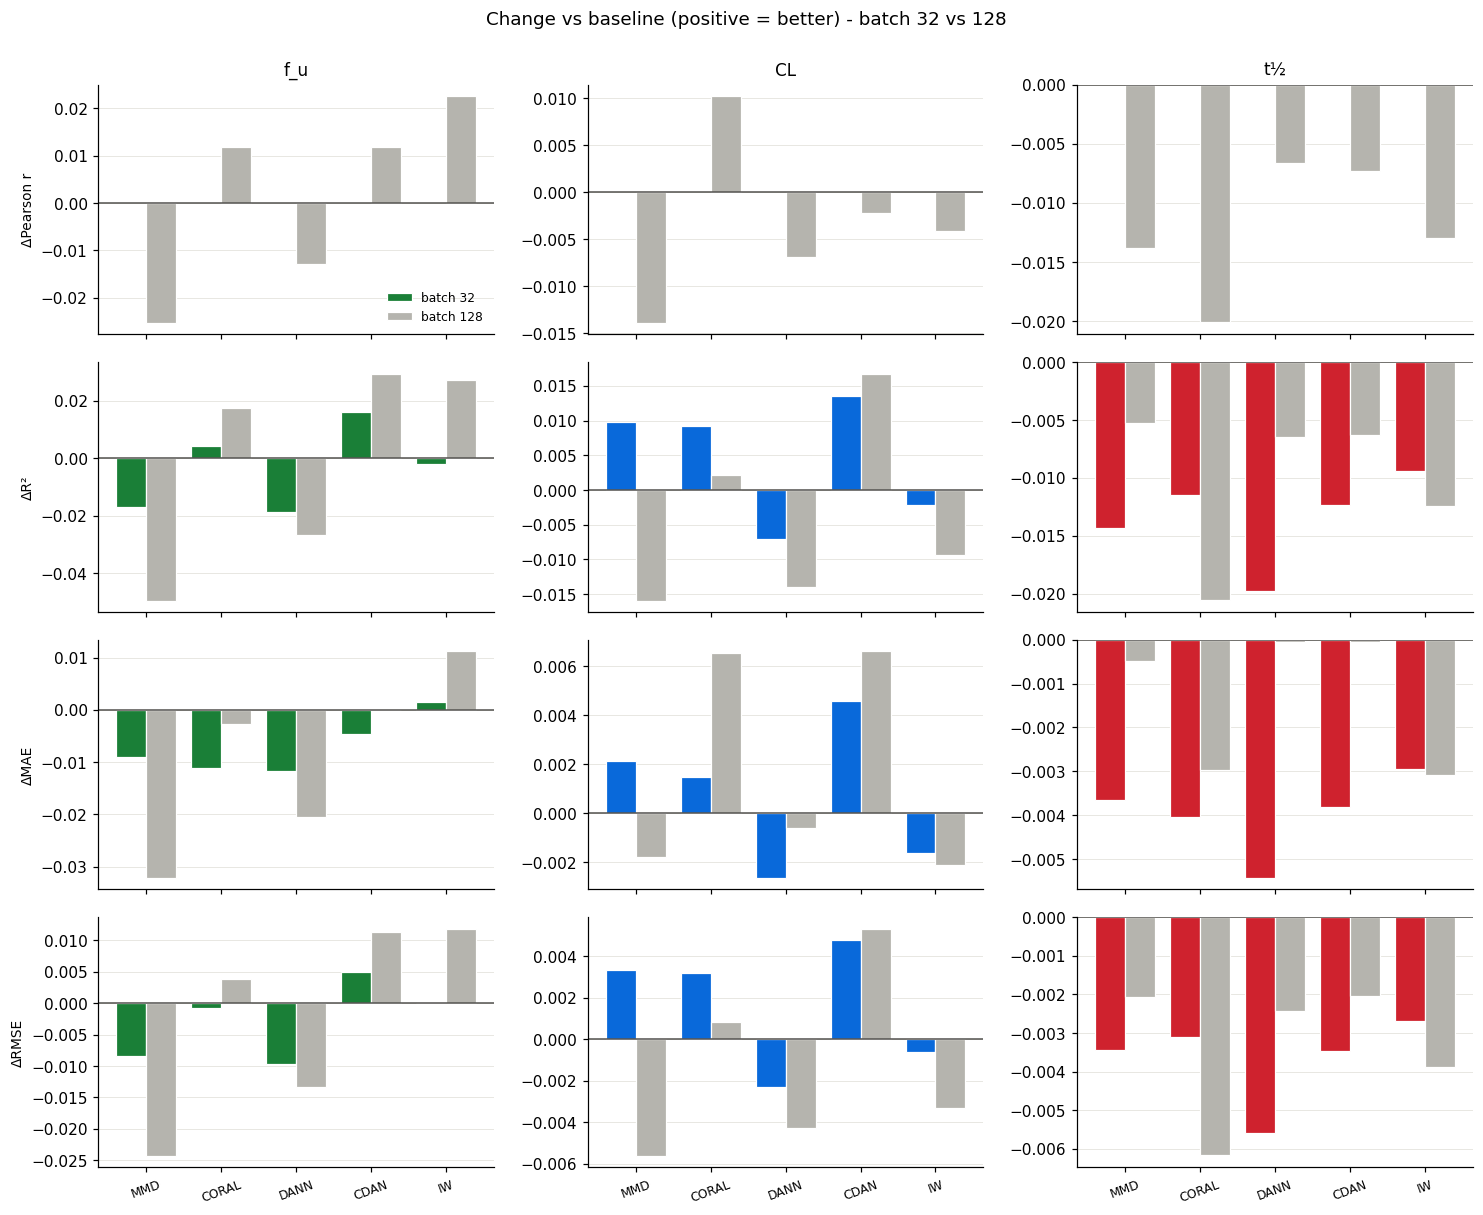

In [4]:
fig, axes = plt.subplots(len(METRICS), len(PROPS), figsize=(13.5, 11), sharex='col')
batches = sorted(runs.batch.unique())
w = 0.8 / len(batches)
for r_i, (col, name, higher) in enumerate(METRICS):
    for c_i, prop in enumerate(PROPS):
        ax = axes[r_i, c_i]
        x = np.arange(len(METHODS))
        for b_i, b in enumerate(batches):
            vals = [delta[(delta.batch == b) & (delta.endpoint == LABEL[prop]) &
                          (delta.method == SHORT[m])][name].mean() for m in METHODS]
            ax.bar(x + (b_i - (len(batches) - 1) / 2) * w, vals, width=w,
                   color=COLOR[prop] if b == 32 else '#b5b4ae',
                   edgecolor='white', linewidth=0.8,
                   label=f'batch {b}' if (r_i == 0 and c_i == 0) else None)
        ax.axhline(0, color='#52514e', lw=1)
        ax.set_xticks(x)
        ax.set_xticklabels([SHORT[m] for m in METHODS], fontsize=8, rotation=20)
        ax.grid(axis='x', visible=False)
        if c_i == 0:
            ax.set_ylabel(f'Δ{name}', fontsize=9)
        if r_i == 0:
            ax.set_title(LABEL[prop], fontsize=11)
axes[0, 0].legend(fontsize=8, frameon=False)
fig.suptitle('Change vs baseline (positive = better) - batch 32 vs 128', fontsize=12, y=1.0)
plt.tight_layout()
plt.savefig(os.path.join(FIG, 'batch_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

## 3. Does a larger batch improve alignment?

`figures/batch_lambda_sweep.csv` holds the results of varying batch size and λ together on f_u,
measuring **domain classifier AUC** (degree of alignment) and **test R²** (predictive performance).

- AUC 0.5 = the two domains cannot be told apart at all (perfect alignment), 1.0 = perfectly separable
- If alignment works as intended, AUC should decrease monotonically as λ grows

auc                      r2                
batch     32      128     256     32      128     256
lam                                                  
0.0    0.8703  0.8779  0.8859  0.2127  0.1688  0.1668
0.1    0.8501  0.8828  0.8752  0.2160  0.2376  0.2046
1.0    0.7290  0.8254  0.8318  0.0554  0.2262  0.2226
10.0   0.6887  0.8202  0.7898 -0.0381 -0.0144  0.0561
100.0  0.7669  0.8235  0.8458 -0.0462 -0.0206 -0.0163

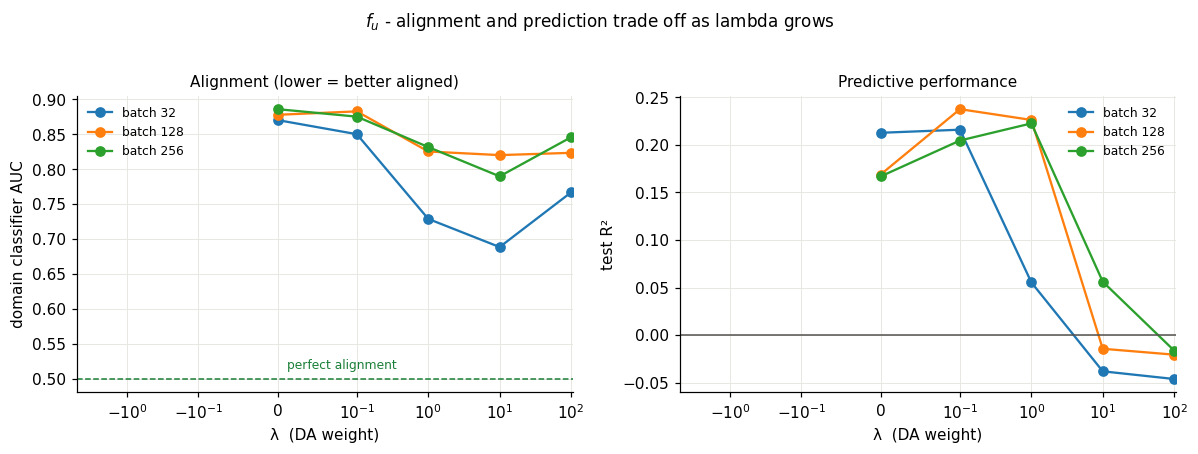

In [5]:
sweep_path = os.path.join(FIG, 'batch_lambda_sweep.csv')
if os.path.exists(sweep_path):
    sw = pd.read_csv(sweep_path)
    piv = sw.groupby(['batch', 'lam'])[['auc', 'r2']].mean().round(4)
    display(piv.unstack('batch'))

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for b in sorted(sw.batch.unique()):
        g = sw[sw.batch == b].groupby('lam')[['auc', 'r2']].mean()
        axes[0].plot(g.index, g['auc'], marker='o', ms=6, label=f'batch {b}')
        axes[1].plot(g.index, g['r2'], marker='o', ms=6, label=f'batch {b}')
    axes[0].axhline(0.5, color='#1a7f37', ls='--', lw=1)
    axes[0].text(0.012, 0.515, 'perfect alignment', fontsize=8, color='#1a7f37')
    axes[0].set_ylabel('domain classifier AUC'); axes[0].set_title('Alignment (lower = better aligned)', fontsize=10)
    axes[1].axhline(0, color='#52514e', lw=1)
    axes[1].set_ylabel('test R²'); axes[1].set_title('Predictive performance', fontsize=10)
    for ax in axes:
        ax.set_xscale('symlog', linthresh=0.1)
        ax.set_xlabel('λ  (DA weight)')
        ax.legend(fontsize=8, frameon=False)
    fig.suptitle('$f_u$ - alignment and prediction trade off as lambda grows', fontsize=11, y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG, 'lambda_alignment_tradeoff.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('batch_lambda_sweep.csv not found')

## 4. Caveats for interpretation

1. **A larger batch means fewer steps** — max_epochs and patience were scaled up to match,
   but the learning rate (1e-3) is unchanged. Large batches usually come with a larger learning rate, so this comparison
   holds under "same learning rate, same number of steps".
2. **Numbers of seeds may differ** — comparisons use the shared seeds, so if the batch 128 run has
   fewer seeds, only those are used (see the output above).
3. **AUC is measured per f_u fold** — 300 source molecules were randomly sampled and compared with target train.
   The numbers differ from the benchmark phase 05 AUC (0.93) because the molecule counts and samples differ;
   read only the **relative change with batch size and λ** here.
4. **Importance Weighting is not an alignment method** — it weights source samples instead of matching distributions.
   It is not a subject of the AUC analysis.